## Cél

Ez a notebook a `quant_train` tábla feature-jeinek szisztematikus minőségellenőrzését végzi solusdt, 1m bontásban.
A 4 elemzési lépés sorban fut: **quality → target_relation → redundancy → stability**.
Az eredmény determinisztikusan kerül a `feature_set.json`-be — nincs manuális szerkesztés.

**Kapcsolódó dokumentáció:**
- Módszertan: `_doc_/2000_features.md`
- Kód-dokumentáció: `_doc_/2010_feature_engineering.md`

**Asset:** SOLUSDT | **Granularitás:** 1m | **Dátum:** 2026-06-19

In [1]:
import json
import logging
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import seaborn as sns
from IPython.display import Markdown, display

_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(_root))
sys.path.insert(0, str(_root / "src"))

import utils
from analyst.table_formatting import display_analysis_table
from modeling.feature_engineering import (
    FeatureEngineeringConfig,
    analyze_quality,
    analyze_redundancy,
    analyze_stability,
    analyze_target_relation,
    materialize_sample_scoped_quant_train,
)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)s  %(message)s",
    datefmt="%H:%M:%S",
)

CQ_COLORS = {
    "blue":       "#1696d2",
    "black":      "#000000",
    "gray_dark":  "#353535",
    "gray":       "#696969",
    "gray_light": "#d2d2d2",
    "yellow":     "#fdbf11",
    "orange":     "#f15a24",
    "red":        "#ec008b",
    "green":      "#55b748",
}
CQ_SEQUENCE = [
    CQ_COLORS["blue"], CQ_COLORS["yellow"], CQ_COLORS["orange"],
    CQ_COLORS["gray"], CQ_COLORS["red"],
]
DECISION_COLORS = {
    "keep":   CQ_COLORS["green"],
    "review": CQ_COLORS["yellow"],
    "drop":   CQ_COLORS["red"],
}

sns.set_theme(
    style="whitegrid",
    rc={
        "figure.figsize":    (9, 5),
        "figure.dpi":        120,
        "axes.spines.top":   False,
        "axes.spines.right": False,
        "axes.edgecolor":    CQ_COLORS["gray"],
        "axes.labelcolor":   CQ_COLORS["gray_dark"],
        "xtick.color":       CQ_COLORS["gray_dark"],
        "ytick.color":       CQ_COLORS["gray_dark"],
        "grid.color":        CQ_COLORS["gray_light"],
        "grid.linewidth":    0.8,
        "axes.axisbelow":    True,
        "legend.frameon":    False,
    },
)
sns.set_palette(CQ_SEQUENCE)

In [2]:
# papermill parameters -- overridden at runtime by pipeline.py
ARTIFACT_DIR = ""
SAMPLE_DIR   = ""
MODEL_ID     = ""
SNAPSHOT_ID  = ""  # optional override; notebook resolves from models.json / reg.models if empty

In [3]:
# Parameters
ARTIFACT_DIR = "D:\\repos\\chronoquant\\artifacts\\lgbm_solusdt_l_fw60_2101_2605"
SAMPLE_DIR = "D:\\repos\\chronoquant\\artifacts\\lgbm_solusdt_l_fw60_2101_2605"
MODEL_ID = "lgbm_solusdt_l_fw60_2101_2605"
SNAPSHOT_ID = "solusdt_fw60_2101_2605__21668185"


In [4]:
RUN_ID = datetime.now().strftime("run_%Y%m%d_%H%M%S")

# Derive asset_id and model direction from MODEL_ID
# Format: lgbm_{asset}_{direction}_fw{horizon}_q{quantile}_{year}
ASSET_ID   = MODEL_ID.split("_")[1] if MODEL_ID else "solusdt"
_direction = MODEL_ID.split("_")[2] if MODEL_ID else "l"
_target    = "long_mfe_fw60" if _direction == "l" else "short_mfe_fw60"

_models_cfg   = utils.load_models_config()
_model_meta   = _models_cfg.get("models", {}).get(MODEL_ID, {})
# SNAPSHOT_ID papermill param -- first priority; fallback: models.json then reg.models
_snapshot_id  = SNAPSHOT_ID if SNAPSHOT_ID else _model_meta.get("sampling", {}).get("snapshot_id")

conn = utils.open_lab_connection(ASSET_ID)
if not _snapshot_id:
    _snapshot_row = conn.execute(
        "SELECT snapshot_id FROM reg.models WHERE model_id = ?",
        [MODEL_ID],
    ).fetchone()
    if _snapshot_row:
        _snapshot_id = _snapshot_row[0]
if not _snapshot_id:
    raise RuntimeError(
        f"Cannot resolve snapshot_id for {MODEL_ID} — run the sample step first or set sampling.snapshot_id."
    )

source_meta = materialize_sample_scoped_quant_train(
    conn,
    model_id=MODEL_ID,
    snapshot_id=_snapshot_id,
)

output_dir = Path(ARTIFACT_DIR) / "feature_engineering"
output_dir.mkdir(parents=True, exist_ok=True)

cfg    = FeatureEngineeringConfig(asset_id=ASSET_ID, run_id=RUN_ID, target_cols=(_target,))
n_rows = source_meta.row_count

display(Markdown(f"""
| Paraméter | Érték |
|-----------|-------|
| model_id  | `{MODEL_ID}` |
| direction | `{_direction}` → target: `{_target}` |
| snapshot  | `{source_meta.snapshot_id}` |
| sample    | `{source_meta.sample_table}` |
| source    | `snap ⋈ model.__sample → temp quant_train` |
| time_range| `{source_meta.min_open_time}` -- `{source_meta.max_open_time}` |
| run_id    | `{RUN_ID}` |
| output    | `{output_dir}` |
| sorok     | **{n_rows:,}** |
"""))

11:02:46  INFO  ensure_registry: path=D:\repos\chronoquant\database/_registry/registry.duckdb newly_applied=[]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


| Paraméter | Érték |
|-----------|-------|
| model_id  | `lgbm_solusdt_l_fw60_2101_2605` |
| direction | `l` → target: `long_mfe_fw60` |
| snapshot  | `solusdt_fw60_2101_2605__21668185` |
| sample    | `model."lgbm_solusdt_l_fw60_2101_2605__sample"` |
| source    | `snap ⋈ model.__sample → temp quant_train` |
| time_range| `2021-01-01 00:58:00` -- `2026-05-31 23:50:00` |
| run_id    | `run_20260622_110246` |
| output    | `D:\repos\chronoquant\artifacts\lgbm_solusdt_l_fw60_2101_2605\feature_engineering` |
| sorok     | **47,448** |


## Quality — Univariáns minőség szűrés

**Mi ez.** Minden `feat_*` oszlopra kiszámítjuk a null arányt, az inf értékek arányát, a varianciát és az outlier hányadot (|z-score| > 3).

**Forrás.** `quant_train` tábla, összes `feat_*` oszlop.

**Értelmezés.** `drop` = null_rate > 0.01 VAGY inf_rate > 0.001 VAGY variance < 1e-8; `review` = outlier_ratio > 0.05 (és nincs drop ok); `keep` = minden más. Az első 1441 sor null az t-1 lag warmup miatt — ez nem minőségi hiba, a sampling garantálja, hogy ezek nem kerülnek a tanítási ablakba.

In [5]:
#| label: tbl-quality-decisions
#| tbl-cap: "Feature quality döntések — összes feature"

quality_df = analyze_quality(conn, cfg)
display_analysis_table(quality_df.to_pandas())

11:04:58  INFO  analyze_quality: 208 features, 47448 rows


11:05:00  INFO  analyze_quality: done — keep=204 drop=2 review=2


feature,null_rate,inf_rate,variance,outlier_ratio,decision,drop_reason
feat_rsi_14,0.00%,0.00%,127.042,0.27%,keep,nan
feat_roc_14,0.00%,0.00%,0.367,1.67%,keep,nan
feat_roc_140,0.00%,0.00%,3.581,1.78%,keep,nan
feat_stoch_k_14,0.00%,0.00%,887.345,0.00%,keep,nan
feat_stoch_d_14,0.00%,0.00%,764.097,0.00%,keep,nan
feat_williams_r_14,0.00%,0.00%,887.345,0.00%,keep,nan
feat_cci_20,0.00%,0.00%,12211.063,0.17%,keep,nan
feat_adx_pos_14,0.00%,0.00%,58.389,0.57%,keep,nan
feat_adx_neg_14,0.00%,0.00%,58.550,0.52%,keep,nan
feat_adx_14,0.00%,0.00%,102.939,1.06%,keep,nan


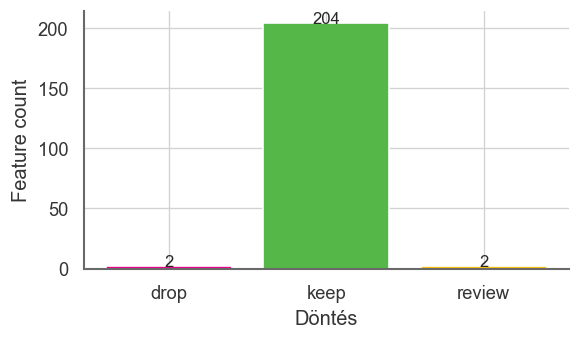

In [6]:
#| label: fig-quality-decisions
#| fig-cap: "Quality döntések megoszlása"
#| fig-alt: "Oszlopdiagram: keep/review/drop döntések száma"

vc = quality_df["decision"].value_counts().sort("decision")
labels = vc["decision"].to_list()
counts = vc["count"].to_list()

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(labels, counts, color=[DECISION_COLORS.get(l, CQ_COLORS["gray"]) for l in labels])
ax.set_xlabel("Döntés")
ax.set_ylabel("Feature count")
for i, v in enumerate(counts):
    ax.text(i, v + 0.3, str(v), ha="center", fontsize=10)
plt.tight_layout()
plt.show()

In [7]:
#| label: tbl-quality-nokeep
#| tbl-cap: "Nem-keep quality döntések részletei"

not_keep_q = quality_df.filter(pl.col("decision") != "keep").select(
    ["feature", "null_rate", "inf_rate", "variance", "outlier_ratio", "decision", "drop_reason"]
).sort("decision")

display(Markdown(f"**Nem-keep features:** {len(not_keep_q)}"))
display_analysis_table(not_keep_q.to_pandas())

**Nem-keep features:** 4

feature,null_rate,inf_rate,variance,outlier_ratio,decision,drop_reason
feat_gap_open_abs_sma_10,0.00%,0.00%,0.000,1.91%,drop,variance=5.07e-09 < min=1e-08
feat_gap_open_abs_sma_30,0.00%,0.00%,0.000,1.87%,drop,variance=4.52e-09 < min=1e-08
feat_doji,0.01%,0.00%,0.086,9.56%,review,nan
feat_outside_bar,0.00%,0.00%,0.072,7.82%,review,nan


## Target Relation — Szignálerősség

**Mi ez.** Minden `feat_*` × target párra Pearson és Spearman korrelációt számítunk a `quant_train` táblán. `signal_proxy = |ρ_spearman|`.

**Forrás.** `quant_train` tábla, `feat_*` és `long_mfe_fw60`, `short_mfe_fw60` oszlopok.

**Értelmezés.** `leakage` = |ρ| > 0.95 (gyanús); `weak` = |ρ| < 0.01 (nincs szignál); `keep` = minden más. Egy feature akkor kerül ki, ha **mindkét** targetre `weak` (vagy `leakage`).

In [8]:
#| label: tbl-relation-head
#| tbl-cap: "Target relation — top 10 sor (signal_proxy szerint rendezve)"

relation_df = analyze_target_relation(conn, cfg)
display_analysis_table(
    relation_df.sort("signal_proxy", descending=True).head(10).to_pandas()
)

11:05:03  INFO  analyze_target_relation: 208 features × 1 targets


11:05:11  INFO  analyze_target_relation: done — keep=164 weak=44 leakage=0


feature,target,pearson_r,spearman_rho,signal_proxy,leakage_flag,decision
feat_natr_14,long_mfe_fw60,0.455,0.366,0.366,False,keep
feat_parkinson_vol_60,long_mfe_fw60,0.442,0.362,0.362,False,keep
feat_gk_vol_60,long_mfe_fw60,0.441,0.361,0.361,False,keep
feat_parkinson_vol_30,long_mfe_fw60,0.437,0.359,0.359,False,keep
feat_gk_vol_30,long_mfe_fw60,0.437,0.359,0.359,False,keep
feat_gk_vol_10,long_mfe_fw60,0.430,0.352,0.352,False,keep
feat_parkinson_vol_10,long_mfe_fw60,0.431,0.352,0.352,False,keep
feat_neg_return_mean_60,long_mfe_fw60,0.429,0.346,0.346,False,keep
feat_hist_vol_20,long_mfe_fw60,0.425,0.346,0.346,False,keep
feat_pos_return_mean_60,long_mfe_fw60,0.429,0.345,0.345,False,keep


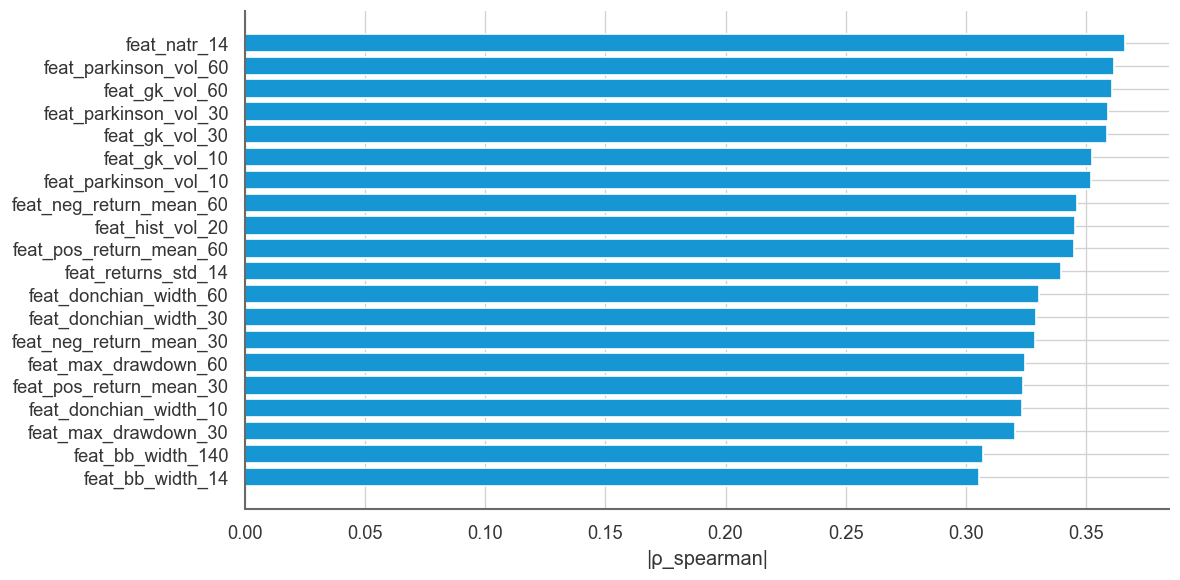

In [9]:
#| label: fig-relation-top20
#| fig-cap: "Top 20 feature signal_proxy értéke targetenként"
#| fig-alt: "Vízszintes oszlopdiagram: top 20 feature Spearman korrelációja long és short targettel"
#| fig-subcap:
#|   - "long_mfe_fw60"
#|   - "short_mfe_fw60"
#| layout-ncol: 1

for target in cfg.target_cols:
    sub = (
        relation_df
        .filter(pl.col("target") == target)
        .sort("signal_proxy", descending=True)
        .head(20)
    ).to_pandas()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(sub["feature"], sub["signal_proxy"], color=CQ_COLORS["blue"])
    ax.invert_yaxis()
    ax.set_xlabel("|ρ_spearman|")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

In [10]:
#| label: tbl-relation-nokeep
#| tbl-cap: "Nem-keep (feature, target) párok"

not_keep_r = relation_df.filter(pl.col("decision") != "keep").sort(["feature", "target"])
display(Markdown(f"**Nem-keep (feature, target) párok:** {len(not_keep_r)}"))
display_analysis_table(not_keep_r.to_pandas())

**Nem-keep (feature, target) párok:** 44

feature,target,pearson_r,spearman_rho,signal_proxy,leakage_flag,decision
feat_adx_neg_14,long_mfe_fw60,-0.030,-0.007,0.007,False,weak
feat_atr_dist_high_60,long_mfe_fw60,-0.011,0.008,0.008,False,weak
feat_bb_width_rank_20,long_mfe_fw60,0.003,0.003,0.003,False,weak
feat_close_position,long_mfe_fw60,-0.003,-0.001,0.001,False,weak
feat_day_open_return,long_mfe_fw60,-0.001,-0.005,0.005,False,weak
feat_day_range_position,long_mfe_fw60,0.017,-0.002,0.002,False,weak
feat_directional_agreement_10_30,long_mfe_fw60,0.000,-0.001,0.001,False,weak
feat_donchian_breakout_30,long_mfe_fw60,-0.010,-0.008,0.008,False,weak
feat_donchian_breakout_60,long_mfe_fw60,-0.004,-0.006,0.006,False,weak
feat_efficiency_ratio_10,long_mfe_fw60,0.013,0.010,0.010,False,weak


## Redundancy — Korrelációs klaszterezés

**Mi ez.** A `feat_*` oszlopokat Pearson korrelációs mátrix alapján klaszterezzük (union-find). Ha két feature |Pearson r| ≥ 0.95, egy klaszterbe kerülnek. Klaszterenként egy reprezentatív marad (`keep`), a többi `drop`.

**Forrás.** `quant_train` tábla, 500 000 véletlen sorból számított korrelációs mátrix.

**Értelmezés.** Reprezentatív = legkisebb indexű feature a klaszterben. A downstream `02_hyper_param_search.py` LightGBM feature importance-on keresztül tovább szűrhet.

In [11]:
#| label: tbl-redundancy-head
#| tbl-cap: "Redundancy analízis — top 10 sor"

redundancy_df = analyze_redundancy(conn, cfg)
display_analysis_table(redundancy_df.head(10).to_pandas())

11:05:12  INFO  analyze_redundancy: 208 features, sample=47448 / 47448 rows


11:05:42  INFO  analyze_redundancy: done — 203 clusters, 5 redundant features dropped


feature,cluster_id,is_representative,max_pearson,decision,drop_reason
feat_rsi_14,0,True,0.000,keep,nan
feat_roc_14,1,True,0.000,keep,nan
feat_roc_140,2,True,0.000,keep,nan
feat_stoch_k_14,4,True,1.000,keep,nan
feat_stoch_d_14,3,True,0.911,keep,nan
feat_williams_r_14,4,False,1.000,drop,redundant in cluster_4; representative=feat_stoch_k_14
feat_cci_20,5,True,0.000,keep,nan
feat_adx_pos_14,6,True,0.000,keep,nan
feat_adx_neg_14,7,True,0.000,keep,nan
feat_adx_14,8,True,0.000,keep,nan


In [12]:
#| label: tbl-redundancy-dropped
#| tbl-cap: "Redundáns (drop) feature-ök klaszter szerinti bontásban"

n_clusters = redundancy_df["cluster_id"].n_unique()
n_multi    = (
    redundancy_df.group_by("cluster_id")
    .agg(pl.len().alias("n"))
    .filter(pl.col("n") > 1)
    .height
)
n_dropped  = (redundancy_df["decision"] == "drop").sum()

display(Markdown(
    f"**Klaszterek:** {n_clusters} összesen, {n_multi} darab >1 taggal — "
    f"**{n_dropped} redundáns feature kizárva.**"
))

dropped_red = redundancy_df.filter(pl.col("decision") == "drop").select(
    ["feature", "cluster_id", "max_pearson", "drop_reason"]
).sort("cluster_id")
display_analysis_table(dropped_red.to_pandas())

**Klaszterek:** 203 összesen, 5 darab >1 taggal — **5 redundáns feature kizárva.**

feature,cluster_id,max_pearson,drop_reason
feat_williams_r_14,4,1.000,redundant in cluster_4; representative=feat_stoch_k_14
feat_quote_volume_ratio_10,45,0.000,redundant in cluster_45; representative=feat_volume_ratio_14
feat_taker_buy_quote_ratio_10,53,0.000,redundant in cluster_53; representative=feat_taker_buy_base_ratio_10
feat_taker_flow_confirmed_return_30,104,0.000,redundant in cluster_104; representative=feat_taker_flow_confirmed_return_10
feat_donchian_position_10,182,0.958,redundant in cluster_182; representative=feat_recovery_ratio_10


## Stability — Időbeli stabilitás

**Mi ez.** Az adatot 90 napos, nem-átfedő időablakokra osztjuk. Minden (feature, bucket) párra Spearman korrelációt számítunk mindkét targettel és összehasonlítjuk a globális baseline-nal. `drift = |ρ_bucket − ρ_baseline|`.

**Forrás.** `quant_train` tábla, összes `feat_*` oszlop, 90 napos bucket-ek.

**Értelmezés.** `stable` ≤ 0.15; `review` 0.15–0.30; `unstable` > 0.30 (nem utolsó 2 bucket); `decayed` > 0.30 **és** utolsó 2 bucket → kizárjuk. A `decayed` flag azt jelenti, hogy a feature a legutóbbi adatszakaszban elveszítette prediktív kapcsolatát.

In [13]:
#| label: tbl-stability-head
#| tbl-cap: "Stability analízis — top 10 sor"

stability_df = analyze_stability(conn, cfg)
display(Markdown(f"**Összes (feature, bucket) sor:** {len(stability_df):,}"))
display_analysis_table(stability_df.head(10).to_pandas())

11:05:43  INFO  analyze_stability: 208 features, bucket_days=90, base_ts=2021-01-01 00:58:00


11:06:11  INFO  analyze_stability: done — 4715 (feature, bucket) rows


**Összes (feature, bucket) sor:** 4,715

feature,bucket_idx,bucket_start,bucket_end,n,null_rate,mean,std,spearman_long,spearman_short,drift_long,drift_short,stability_flag
feat_rsi_14,0,2021-01-01 00:58:00,2021-02-15 23:22:00,1104,0.00%,50.536,13.057,0.021,0.036,0.040,0.035,stable
feat_rsi_14,1,2021-02-16 00:48:00,2021-05-15 23:03:00,2136,0.00%,50.495,12.407,0.026,0.054,0.044,0.052,stable
feat_rsi_14,2,2021-05-16 00:26:00,2021-08-14 23:05:00,2184,0.00%,50.222,11.102,-0.030,0.002,0.012,0.000,stable
feat_rsi_14,3,2021-08-15 00:20:00,2021-11-11 23:20:00,2136,0.00%,50.098,11.059,-0.046,-0.077,0.028,0.079,stable
feat_rsi_14,4,2021-11-12 00:05:00,2022-02-10 23:02:00,2184,0.00%,49.734,11.382,-0.015,0.008,0.003,0.007,stable
feat_rsi_14,5,2022-02-11 00:35:00,2022-05-10 23:00:00,2136,0.00%,49.944,11.420,-0.020,0.029,0.002,0.028,stable
feat_rsi_14,6,2022-05-11 00:01:00,2022-08-09 23:10:00,2184,0.00%,49.746,11.647,-0.061,-0.024,0.043,0.025,stable
feat_rsi_14,7,2022-08-10 00:58:00,2022-11-06 23:32:00,2136,0.00%,50.306,10.925,-0.024,0.006,0.006,0.004,stable
feat_rsi_14,8,2022-11-07 00:34:00,2023-02-05 23:23:00,2184,0.00%,49.675,10.885,0.013,0.015,0.031,0.014,stable
feat_rsi_14,9,2023-02-06 00:45:00,2023-05-05 23:35:00,2136,0.00%,50.006,10.801,-0.043,0.001,0.025,0.001,stable


In [14]:
#| label: fig-stability-drift
#| fig-cap: "Drift időbeli lefutása — decayed/unstable feature-ök mintája (max 6)"
#| fig-alt: "Vonaldiagram: drift értékek bucket-enként, long és short targetekre"
#| layout-ncol: 1

problematic = (
    stability_df
    .filter(pl.col("stability_flag").is_in(["decayed", "unstable"]))
    ["feature"].unique().to_list()
)

if not problematic:
    display(Markdown("**Nincs decayed/unstable feature** — minden feature stabilan tartja a prediktív kapcsolatát."))
else:
    sample_feats = sorted(problematic)[:6]
    for feat in sample_feats:
        sub = stability_df.filter(pl.col("feature") == feat).sort("bucket_idx").to_pandas()
        fig, ax = plt.subplots(figsize=(10, 3))
        ax.plot(sub["bucket_idx"], sub["drift_long"],  marker="o", label="drift_long",  color=CQ_COLORS["blue"])
        ax.plot(sub["bucket_idx"], sub["drift_short"], marker="s", label="drift_short", color=CQ_COLORS["orange"])
        ax.axhline(cfg.max_drift_threshold, color=CQ_COLORS["red"], linestyle="--",
                   linewidth=1, label=f"threshold ({cfg.max_drift_threshold})")
        ax.legend(fontsize=8)
        ax.set_xlabel("bucket_idx")
        ax.set_ylabel("drift")
        ax.set_xlabel(f"{feat} — bucket_idx")
        plt.tight_layout()
        plt.show()

**Nincs decayed/unstable feature** — minden feature stabilan tartja a prediktív kapcsolatát.

In [15]:
#| label: tbl-stability-decayed
#| tbl-cap: "Decayed feature-ök összesítő statisztikái"

decayed_features = (
    stability_df
    .filter(pl.col("stability_flag") == "decayed")
    ["feature"].unique().to_list()
)
display(Markdown(f"**Decayed (kizárt) features:** {len(decayed_features)}"))

if decayed_features:
    decayed_summary = (
        stability_df
        .filter(pl.col("feature").is_in(decayed_features))
        .group_by("feature")
        .agg([
            pl.col("drift_long").max().alias("max_drift_long"),
            pl.col("drift_short").max().alias("max_drift_short"),
            pl.col("stability_flag")
              .filter(pl.col("stability_flag") == "decayed")
              .len().alias("decayed_buckets"),
        ])
        .sort("max_drift_long", descending=True)
    )
    display_analysis_table(decayed_summary.to_pandas())

**Decayed (kizárt) features:** 0

## Output — feature_set.json

**Mi ez.** A 4 lépés eredményét kombináljuk. Egy feature a `selected` listába kerül, ha: (1) quality → `keep`, (2) target_relation → legalább egy targetre `keep`, (3) redundancy → `keep`, (4) stability → nincs `decayed` bucket.

**Forrás.** A fenti 4 analízis lépés kimenetei.

**Értelmezés.** A `selected` lista adódik tovább a `00_create_sample.py`-nak. `dropped` okkal, `review` marginális (megtartjuk, de jelölt).

In [16]:
conn.close()
output_dir.mkdir(parents=True, exist_ok=True)

all_features = quality_df["feature"].to_list()
created_at   = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

quality_drop   = {r["feature"]: r["drop_reason"] for r in quality_df.iter_rows(named=True) if r["decision"] == "drop"}
quality_review = {r["feature"] for r in quality_df.iter_rows(named=True) if r["decision"] == "review"}

relation_keep = {r["feature"] for r in relation_df.iter_rows(named=True) if r["decision"] == "keep"}
relation_leak = {r["feature"] for r in relation_df.iter_rows(named=True) if r["decision"] == "leakage"}

redundancy_drop = {r["feature"]: r["drop_reason"] for r in redundancy_df.iter_rows(named=True) if r["decision"] == "drop"}

decayed_set  = {r["feature"] for r in stability_df.iter_rows(named=True) if r["stability_flag"] == "decayed"}
unstable_set = {r["feature"] for r in stability_df.iter_rows(named=True) if r["stability_flag"] in ("unstable", "review")} - decayed_set

# Expert filter: permanently exclude time-of-day / session-anchored features
expert_excluded = {
    feat: "expert: time-of-day / session-anchored feature"
    for feat in all_features
    if any(pat in feat for pat in cfg.expert_exclude_patterns)
}

selected: list[str]  = []
dropped:  list[dict] = []
review:   list[str]  = []

for feat in all_features:
    if feat in expert_excluded:
        dropped.append({"col": feat, "reason": expert_excluded[feat]})
        continue

    reasons: list[str] = []
    if feat in quality_drop:
        reasons.append(f"quality: {quality_drop[feat]}")
    if feat in relation_leak:
        reasons.append("relation: leakage suspect")
    if feat not in relation_keep and feat not in relation_leak:
        reasons.append("relation: weak signal across all targets")
    if feat in redundancy_drop:
        reasons.append(f"redundancy: {redundancy_drop[feat]}")
    if feat in decayed_set:
        reasons.append("stability: decayed in recent buckets")

    is_review = (feat in quality_review or feat in unstable_set) and not reasons

    if reasons:
        dropped.append({"col": feat, "reason": " | ".join(reasons)})
    elif is_review:
        review.append(feat)
    else:
        selected.append(feat)

fs = {
    "run_id"     : cfg.run_id,
    "asset_id"   : cfg.asset_id,
    "model_id"   : MODEL_ID,
    "target_col" : cfg.target_cols[0],
    "created_at" : created_at,
    "target_cols": list(cfg.target_cols),
    "selected"   : selected,
    "dropped"    : dropped,
    "review"     : review,
    "provenance" : {
        "snapshot_id"    : source_meta.snapshot_id,
        "sample_table"   : source_meta.sample_table,
        "sample_rows"    : source_meta.sample_row_count,
        "joined_rows"    : source_meta.row_count,
        "min_open_time"  : source_meta.min_open_time,
        "max_open_time"  : source_meta.max_open_time,
        "source_contract": "snap ⋈ model.__sample",
    },
    "thresholds" : {
        "max_null_rate"          : cfg.max_null_rate,
        "max_inf_rate"           : cfg.max_inf_rate,
        "min_variance"           : cfg.min_variance,
        "max_outlier_ratio"      : cfg.max_outlier_ratio,
        "min_spearman_abs"       : cfg.min_spearman_abs,
        "max_spearman_leakage"   : cfg.max_spearman_leakage,
        "pearson_cluster_thr"    : cfg.pearson_cluster_thr,
        "redundancy_max_rows"    : cfg.redundancy_max_rows,
        "stability_bucket_days"  : cfg.stability_bucket_days,
        "max_drift_threshold"    : cfg.max_drift_threshold,
        "expert_exclude_patterns": list(cfg.expert_exclude_patterns),
    },
}

json_path = output_dir / "feature_set.json"
json_path.write_text(json.dumps(fs, indent=2), encoding="utf-8")

11607

In [17]:
#| label: tbl-output-summary
#| tbl-cap: "Feature szelekció végeredmény"

summary_df = pd.DataFrame([
    {"kategória": "selected", "count": len(selected)},
    {"kategória": "review",   "count": len(review)},
    {"kategória": "dropped",  "count": len(dropped)},
])
display_analysis_table(summary_df)

display(Markdown(
    f"**Output:** `{output_dir}` → `feature_set.json` ✓"
))

kategória,count
selected,124
review,30
dropped,54


**Output:** `D:\repos\chronoquant\artifacts\lgbm_solusdt_l_fw60_2101_2605\feature_engineering` → `feature_set.json` ✓

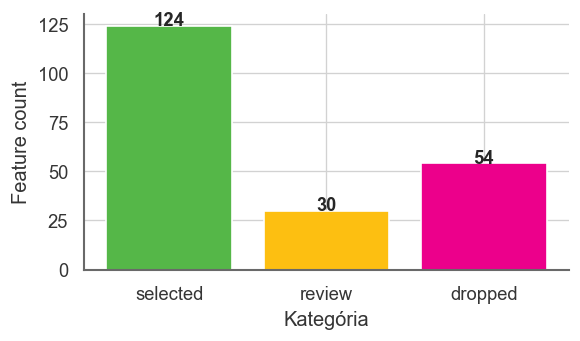

In [18]:
#| label: fig-output-summary
#| fig-cap: "Feature szelekció végeredmény — megoszlás"
#| fig-alt: "Oszlopdiagram: selected/review/dropped feature count"

fig, ax = plt.subplots(figsize=(5, 3))
cats   = ["selected", "review", "dropped"]
values = [len(fs["selected"]), len(fs["review"]), len(fs["dropped"])]
colors = [CQ_COLORS["green"], CQ_COLORS["yellow"], CQ_COLORS["red"]]
ax.bar(cats, values, color=colors)
ax.set_xlabel("Kategória")
ax.set_ylabel("Feature count")
for i, v in enumerate(values):
    ax.text(i, v + 0.3, str(v), ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()